In [1]:
import numpy as np
import matplotlib.pyplot as plt
import galsim as gs

from kl_pipe.tng import (
  TNG50MockData,
  TNG50Galaxy,
  TNGDataVectorGenerator,
  TNGRenderConfig,
  FiberPlacement,
  FiberObservationConfig,
  EmissionConfig,
  FiberSpectraSimulator,
)
from kl_pipe.parameters import ImagePars

temp_dir = '~/kl_roman_pipe/data'

In [2]:
tng = TNG50Galaxy(index=1)
galaxy = tng.get_galaxy()
# tng = TNG50MockData(use_gold=True)
# galaxy = tng[0]
gen = TNGDataVectorGenerator(galaxy)
psfscale = 1.028993969962188
psf = gs.Airy(lam_over_diam=1.0/psfscale, scale_unit=gs.arcsec)
params = {'theta_int': 0.,
          'cosi': 0.3,
          'x0': 0.,
          'y0': 0.,
          'g1': 0.,
          'g2': 0.,}
z = 0.3

In [7]:
image_pars = ImagePars(shape=(96, 96), pixel_scale=0.2637/2, indexing='ij')
render_cfg = TNGRenderConfig(image_pars=image_pars,
                             band='r',                      # Photometric band: 'g', 'r', 'i', 'u', 'z'
                             use_dusted=True,               # Use dust-attenuated luminosities
                             center_on_peak=True,           # Center on luminosity peak (vs subhalo center)
                             use_native_orientation=False,   # Use TNG's native inc/PA (or custom if False)
                             pars=params,                     # Custom orientation params (if use_native_orientation=False)
                             use_cic_gridding=True,         # Cloud-in-Cell (True) vs Nearest-Grid-Point (False)
                             target_redshift=z,           # Scale to z=0.7 for Roman-like sub-arcsec obs (TNG native z~0.01)
                             preserve_gas_stellar_offset=True,  # Keep physical gas-stellar misalignment (default)
                             psf=psf,
                             )
render_cfg_clean = TNGRenderConfig(image_pars=image_pars,
                             band='r',                      # Photometric band: 'g', 'r', 'i', 'u', 'z'
                             use_dusted=True,               # Use dust-attenuated luminosities
                             center_on_peak=True,           # Center on luminosity peak (vs subhalo center)
                             use_native_orientation=False,   # Use TNG's native inc/PA (or custom if False)
                             pars=params,                     # Custom orientation params (if use_native_orientation=False)
                             use_cic_gridding=True,         # Cloud-in-Cell (True) vs Nearest-Grid-Point (False)
                             target_redshift=z,           # Scale to z=0.7 for Roman-like sub-arcsec obs (TNG native z~0.01)
                             preserve_gas_stellar_offset=True,  # Keep physical gas-stellar misalignment (default)
                             )

In [18]:
intensity, var_i = gen.generate_intensity_map(render_cfg, snr=900, seed=42)
intensity_clean, var_i_c = gen.generate_intensity_map(render_cfg_clean, snr=None, seed=42)
velocity, var_v = gen.generate_velocity_map(render_cfg, snr=900, seed=42)
velocity_clean, var_v = gen.generate_velocity_map(render_cfg, snr=900, seed=42, intensity_map=intensity_clean)

/var/tmp/ipykernel_90034/48598769.py:3: UserWarning: PSF set but no intensity_map provided to generate_velocity_map. Generating intensity internally (less efficient).
  velocity, var_v = gen.generate_velocity_map(render_cfg, snr=900, seed=42)


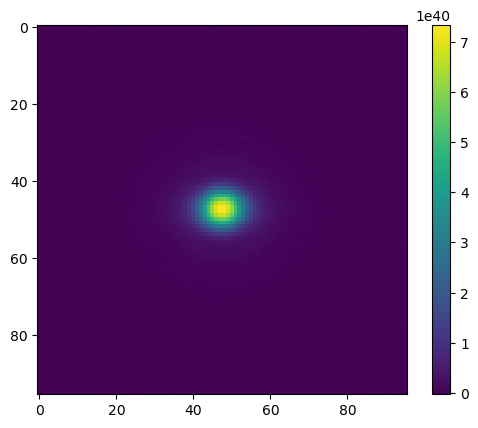

In [16]:
plt.imshow(intensity)
plt.colorbar()

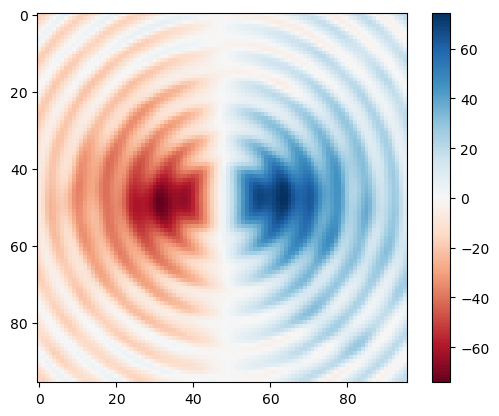

In [20]:
plt.imshow(velocity_clean, cmap='RdBu')
plt.colorbar()

In [19]:
np.mean(velocity)

8.026277518502583e+45

In [7]:
fibers = [
  FiberPlacement(x_arcsec=1.5, y_arcsec=0.0, radius_arcsec=0.75, name='right'),
  FiberPlacement(x_arcsec=-1.5, y_arcsec=0.0, radius_arcsec=0.75, name='left'),
  FiberPlacement(x_arcsec=0.0, y_arcsec=0.0, radius_arcsec=0.75, name='center'),
]

In [8]:
fwhm_pix = 3.4
fwhm_ang = fwhm_pix * 2.355 / 4.
obs_cfg = FiberObservationConfig(wave_min=8510.0,
                                 wave_max=8558.1,
                                 n_wave=61,
                                 exposure_time=180.0,
                                 spectral_fwhm=fwhm_ang,
                                 systemic_redshift=z)

In [9]:
Ha_vac_rest = 6564.6
emission_cfg = EmissionConfig(
    rest_wavelength=Ha_vac_rest,
    emission_flux=1.0,
    intrinsic_sigma_kms=3.0,
    continuum_type='func',
    continuum_func='1.0 - 2e-4*(wave-6564.6)',
    obs_cont_norm_wave=6564.6,
    obs_cont_norm_flam=1.0e-3,
)

In [10]:
sim = FiberSpectraSimulator(image_pars)
result = sim.simulate_from_generator(
  generator=gen,
  render_config=render_cfg,
  fibers=fibers,
  obs_config=obs_cfg,
  emission_config=emission_cfg,
)

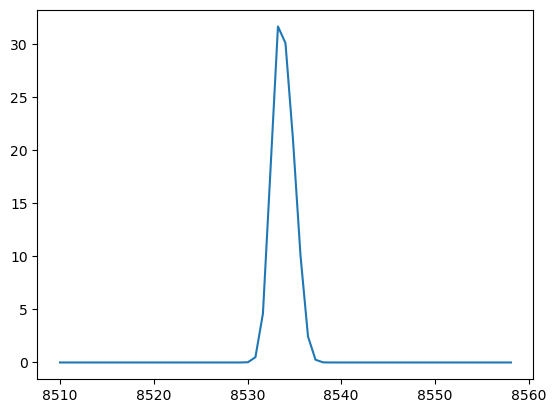

In [12]:
plt.plot(result.wavelengths, result.spectra[2])
# plt.axvline(Ha_vac_rest*(1+z), color='black', lw=0.5)